<div align="center">
  <img src="https://github.com/ajayvdatascience/image/blob/main/22078e1b-221d-4959-9cc0-b79ffd8f19b4.png?raw=true" width="200%">
</div>



<center><font size=10></center></font>
<center><font size=6>Embeddings to Transformers</center></font>

# **Problem Statement**

## **Business Context**

Streamora is an OTT platform that recommends movies based on titles, descriptions, and genres. However, many users ignore these recommendations and search for movies manually. This project aims to improve the recommendation system by providing more personalized movie suggestions, increasing user engagement and customer satisfaction.

##  **Objective**

The current recommendation system does not effectively match user preferences. This project analyzes 11 months of viewing history and develops an AI-based movie recommendation system to provide personalized suggestions, improve user engagement, increase customer satisfaction, and encourage higher content consumption.

## **Data Description**

**Movie Data**

* **title**: Name of the movie.
* **genres**: Space-separated list of genres associated with the movie (e.g., *Action Drama*).
* **overview**: Short summary describing the movie plot or storyline.




**Evaluation Data**

* **movie\_1** to **movie\_7**: Individual columns representing the 7 most recently watched movies by the user.
* **date**: Date on which the evaluation or recommendation is recorded.
* **movie\_watch**: The movie the user actually watched after the recommendation.
* **past_success**: Indicates whether the previous model correctly recommended the watched movie (`True`/`False`).


# **Importing Necessary Libraries**

| Package                   | Use                                                                   |
| ------------------------- | --------------------------------------------------------------------- |
| **NumPy**                 | Performs numerical computations and array operations.                 |
| **Scikit-learn**          | Builds and evaluates machine learning models.                         |
| **SciPy**                 | Provides scientific and mathematical computing functions.             |
| **Gensim**                | Processes text data and generates document embeddings.                |
| **Sentence Transformers** | Converts text into semantic vector embeddings for similarity search.  |
| **Gradio**                | Creates interactive web interfaces for machine learning applications. |
| **Pandas**                | Loads, cleans, manipulates, and analyzes structured data.             |


In [ ]:
!pip install \
    numpy==1.26.4 \
    scikit-learn==1.6.1\
    scipy==1.13.1\
    gensim==4.3.3 \
    sentence-transformers==3.4.1 \
    gradio==5.33.0\
    pandas==2.2.2

In [ ]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import random

# Set seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

*   The required Python libraries were imported successfully. These libraries are used for data preprocessing, visualization, text analysis, and building the movie recommendation model.

*   The random seed is set to ensure consistent and reproducible results across multiple executions of the program.

# **Loading the Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Movie_dataset_title.csv** contains movie information used to generate personalized movie recommendations.


In [ ]:
movie_data = pd.read_csv('/content/drive/MyDrive/GEN AI DATASET/movie_dataset_title.csv')


**evaluation_data.csv** contains test data used to evaluate the performance and accuracy of the movie recommendation system.


In [ ]:
evaluation_data=pd.read_csv('/content/drive/MyDrive/GEN AI DATASET/Evaluation_Data.csv')

In [ ]:
evaluation_data.head()

,movie_1,movie_2,movie_3,movie_4,movie_5,movie_6,movie_7,date,movie_watch,past_success
0,The Last Emperor,The Conjuring 2,Conspiracy Theory,Who Killed the Electric Car?,Skyline,No Escape,Big Momma's House,2024-01-01,Cotton Comes to Harlem,True
1,Face/Off,The Hunger Games: Mockingjay - Part 1,All Good Things,Ray,Extraordinary Measures,Notting Hill,Teeth and Blood,2024-01-01,Desert Blue,False
2,The Spectacular Now,Love and Death on Long Island,August Rush,May,Sunday School Musical,Battle of the Year,Broken City,2024-01-01,Crazy/Beautiful,True
3,Ace Ventura: Pet Detective,Joe Dirt,The Cat in the Hat,Roll Bounce,Navy Seals vs. Zombies,The Lost Weekend,Lethal Weapon 3,2024-01-01,Welcome Home Roscoe Jenkins,False
4,Pontypool,Up,Reservoir Dogs,Religulous,Blood Work,The Help,Raiders of the Lost Ark,2024-01-01,Free State of Jones,False


# **Data Overview**

## **Movie Data**

In [ ]:
movie_data.shape

(4803, 3)

The dataset consists of 4803 rows and 3 columns

In [ ]:
movie_data.head(10)


,genres,overview,title
0,Action Adventure Fantasy Science Fiction,"In the 22nd century, a paraplegic Marine is di...",Avatar
1,Adventure Fantasy Action,"Captain Barbossa, long believed to be dead, ha...",Pirates of the Caribbean: At World's End
2,Action Adventure Crime,A cryptic message from Bond’s past sends him o...,Spectre
3,Action Crime Drama Thriller,Following the death of District Attorney Harve...,The Dark Knight Rises
4,Action Adventure Science Fiction,"John Carter is a war-weary, former military ca...",John Carter
5,Fantasy Action Adventure,The seemingly invincible Spider-Man goes up ag...,Spider-Man 3
6,Animation Family,When the kingdom's most wanted-and most charmi...,Tangled
7,Action Adventure Science Fiction,When Tony Stark tries to jumpstart a dormant p...,Avengers: Age of Ultron
8,Adventure Fantasy Family,"As Harry begins his sixth year at Hogwarts, he...",Harry Potter and the Half-Blood Prince
9,Action Adventure Fantasy,Fearing the actions of a god-like Super Hero l...,Batman v Superman: Dawn of Justice


In [ ]:
movie_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   genres    4775 non-null   object
 1   overview  4800 non-null   object
 2   title     4803 non-null   object
dtypes: object(3)
memory usage: 112.7+ KB


The dataset contains 4,803 movie records with 3 key features:

- title: Movie name — available for all entries.
- overview: Missing in 3 records.
- genres: Missing in 28 records.

In [ ]:
movie_data.dropna(inplace=True)

In [ ]:
movie_data.reset_index(drop=True, inplace=True)

*   The dataset dimensions were identified, giving an overview of the dataset size.  

*   The first few records were displayed successfully, allowing us to verify that the dataset was loaded correctly.

*   The dataset structure, data types, and missing values were successfully identified, helping us understand the dataset before preprocessing.

*   Missing values were removed, resulting in a cleaner dataset for analysis and model development.

*  The dataset index was reset successfully, making the data organized and easier to process.


## **Evaluation Data**

In [ ]:
evaluation_data.shape

(2000, 10)

The dataset consists of 2000 rows and 10 columns

In [ ]:
evaluation_data.head(10)

,movie_1,movie_2,movie_3,movie_4,movie_5,movie_6,movie_7,date,movie_watch,past_success
0,The Last Emperor,The Conjuring 2,Conspiracy Theory,Who Killed the Electric Car?,Skyline,No Escape,Big Momma's House,2024-01-01,Cotton Comes to Harlem,True
1,Face/Off,The Hunger Games: Mockingjay - Part 1,All Good Things,Ray,Extraordinary Measures,Notting Hill,Teeth and Blood,2024-01-01,Desert Blue,False
2,The Spectacular Now,Love and Death on Long Island,August Rush,May,Sunday School Musical,Battle of the Year,Broken City,2024-01-01,Crazy/Beautiful,True
3,Ace Ventura: Pet Detective,Joe Dirt,The Cat in the Hat,Roll Bounce,Navy Seals vs. Zombies,The Lost Weekend,Lethal Weapon 3,2024-01-01,Welcome Home Roscoe Jenkins,False
4,Pontypool,Up,Reservoir Dogs,Religulous,Blood Work,The Help,Raiders of the Lost Ark,2024-01-01,Free State of Jones,False
5,National Lampoon's Vacation,The Queen,Carrie,西游记之孙悟空三打白骨精,Obvious Child,Promised Land,Julia,2024-01-01,Big,True
6,Open Range,The Last Shot,The Secret Life of Walter Mitty,East Is East,Phantasm II,Epic,Secret Window,2024-01-02,Chain of Command,False
7,E.T. the Extra-Terrestrial,L!fe Happens,Getaway,Godsend,Hoot,Alive,The Caveman's Valentine,2024-01-02,Thr3e,False
8,Amnesiac,X-Men: The Last Stand,What to Expect When You're Expecting,Inside Man,De jurk,It's All Gone Pete Tong,Need for Speed,2024-01-02,Pride & Prejudice,False
9,Show Boat,The River Wild,Let's Be Cops,Toy Story 2,Rien ne va plus,La sirène du Mississipi,もののけ姫,2024-01-02,The Incredibly True Adventure of Two Girls In ...,False


In [ ]:
evaluation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie_1       2000 non-null   object
 1   movie_2       2000 non-null   object
 2   movie_3       2000 non-null   object
 3   movie_4       2000 non-null   object
 4   movie_5       2000 non-null   object
 5   movie_6       2000 non-null   object
 6   movie_7       2000 non-null   object
 7   date          2000 non-null   object
 8   movie_watch   2000 non-null   object
 9   past_success  2000 non-null   bool  
dtypes: bool(1), object(9)
memory usage: 142.7+ KB


The dataset contains 2,000 complete records with movie history, current movie, recommendation success, and date information. Since there are no missing values, the dataset is clean and suitable for building the movie recommendation system.

# **EDA**

**Exploratory Data Analysis (EDA)** is used to understand the dataset by analyzing its structure, patterns, and key features before building the recommendation model.


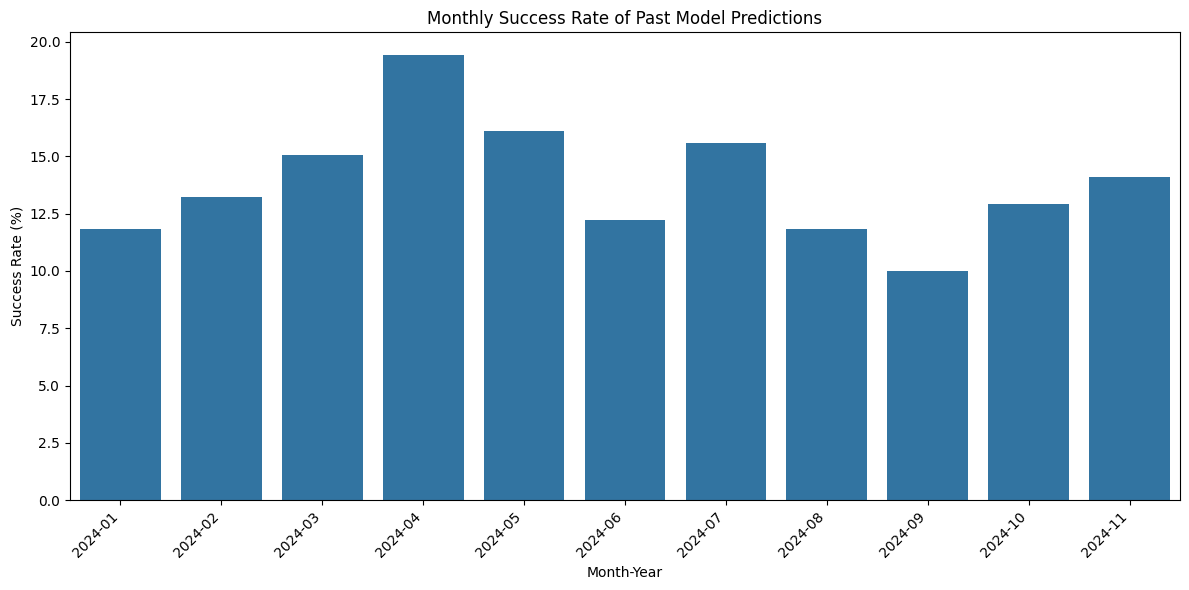

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'date' column to datetime objects
# This is necessary to extract month and year information easily.
evaluation_data['date'] = pd.to_datetime(evaluation_data['date'])

# Extract month and year from the 'date' column
# We combine year and month to group data by calendar month across years.
evaluation_data['month_year'] = evaluation_data['date'].dt.to_period('M')

# Group by month and count the occurrences of each 'Past success' value
# This gives us the total count of True and False successes for each month.
monthly_success_counts = evaluation_data.groupby('month_year')['past_success'].value_counts().unstack(fill_value=0)

# Calculate the percentage of 'True' success for each month
# We divide the count of True successes by the total count (True + False) for that month and multiply by 100.
monthly_success_counts['Success Percentage'] = (monthly_success_counts[True] / (monthly_success_counts[True] + monthly_success_counts[False])) * 100

# Sort the data by month and year
# This ensures the plot displays the months in chronological order.
monthly_success_counts = monthly_success_counts.sort_index()

# Create the plot
# We use seaborn for a visually appealing bar plot.
plt.figure(figsize=(12, 6)) # Set the size of the figure for better readability
sns.barplot(x=monthly_success_counts.index.astype(str), y='Success Percentage', data=monthly_success_counts) # Create a bar plot with month_year on x-axis and Success Percentage on y-axis. Use a colormap 'viridis'.

# Add labels and title to the plot
plt.xlabel('Month-Year') # Label for the x-axis
plt.ylabel('Success Rate (%)') # Label for the y-axis
plt.title('Monthly Success Rate of Past Model Predictions') # Title of the plot
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability, especially if there are many months
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()

**Observation**

* The previous recommendation model showed inconsistent performance.
* The success rate ranged from **10% to 19.4%**.
* Recommendation accuracy was low.
* The existing system needs improvement.
* A more personalized recommendation model is required.


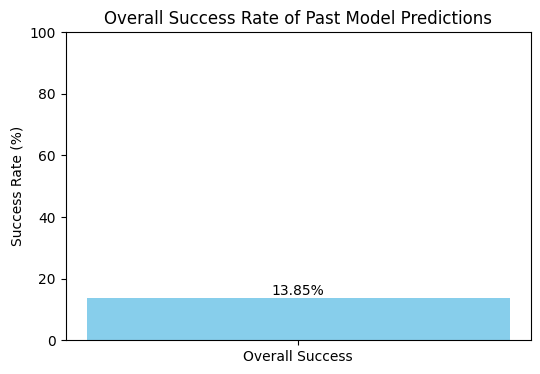

In [ ]:
# Calculate the overall success percentage
overall_success_percentage = (evaluation_data['past_success'].sum() / len(evaluation_data)) * 100

# Create a figure and an axes
fig, ax = plt.subplots(figsize=(6, 4))

# Create a bar plot for overall success
ax.bar(['Overall Success'], [overall_success_percentage], color='skyblue')

# Add the percentage value on top of the bar
ax.text('Overall Success', overall_success_percentage + 1, f'{overall_success_percentage:.2f}%', ha='center')

# Add labels and title
ax.set_ylabel('Success Rate (%)')
ax.set_title('Overall Success Rate of Past Model Predictions')
ax.set_ylim(0, 100) # Set y-axis limit to 0-100%

# Display the plot
plt.show()

**Observation**

* The previous model achieved only **13.85%** recommendation success.
* Recommendation accuracy was low.
* The existing system showed poor performance.
* A more effective AI-based movie recommendation system was required.


# Model Building

In this project experiment **two different approaches** to generate vector representations of movie metadata:

1. **Word2Vec-based model** – which learns word-level embeddings from tokenized text inputs.

2. **Sentence Transformer-based model** – which captures semantic meaning at the sentence level using pre-trained transformer architectures.

## Word2Vec

Word2Vec is an NLP technique that converts words into meaningful numerical vectors. It learns the relationship between words based on their context, allowing the recommendation system to identify similar movies and provide personalized suggestions.

### Model Building

#### <font size=4>**Step 1: Text Preperation**

In [ ]:
data_word2vec=movie_data.copy()

In [ ]:
from gensim.utils import simple_preprocess
data_word2vec['text'] = data_word2vec['title'] + ' ' + data_word2vec['genres'].replace('|', ' ', regex=True) + ' ' + data_word2vec['overview']
data_word2vec['tokens'] = data_word2vec['text'].apply(lambda x: simple_preprocess(x))

The movie data was cleaned and preprocessed successfully, making it ready for Word2Vec training and improving the accuracy of the recommendation system.

####<font size=4>**Step 2: Model Training**

In [ ]:
model_word2vec = Word2Vec(sentences=data_word2vec['tokens'], vector_size=100, window=5, min_count=1, workers=4,seed=42)

Short explanation of Word2Vec hyperparameters used:

* **`sentences`**: Input data — list of tokenized sentences (your `tokens` column).
* **`vector_size=100`**: Size of the word embeddings (each word is represented by a 100-dimensional vector).
* **`window=5`**: Context window size — the number of words before and after a target word to consider for training.
* **`min_count=1`**: Ignores words with total frequency lower than 1 (i.e., includes all words).
* **`workers=4`**: Number of CPU cores used for parallel training.
* **`seed=42`**: Random seed to ensure reproducibility.


#### <font size=4>**Step 3: Average Vector Calculation**

In [ ]:
def get_avg_word_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)


The average vector represents the user's overall movie preferences by combining all watched movie vectors into a single vector. It is used to generate accurate and personalized movie recommendations.

#### <font size=4>**Step 4: Embedding Computation**

Converts each word into a fixed-length vector based on its content. These vectors help the system compare how similar different items are.

In [ ]:
data_word2vec['embedded_vector'] = data_word2vec['tokens'].apply(lambda x: get_avg_word_vector(x, model_word2vec))

In this code:
- It calculates the average word vector for each list of tokens using the Word2Vec model.


#### <font size=4>**Step 5: Generating Recommedations**




* The user's recently watched movies are used to understand their preferences.
* Cosine similarity identifies movies with similar content.
* Already watched movies are excluded from recommendations.
* The system provides fresh, relevant, and personalized movie suggestions.


In [ ]:
def word2vec_recommendations(recently_watched_titles, data, model, n_recommendations=10):

    # Get embeddings for the recently watched movies
    watched_embeddings = []
    for title in recently_watched_titles:
        movie_row = data[data['title'] == title]
        if not movie_row.empty:
            watched_embeddings.append(movie_row.iloc[0]['embedded_vector'])

    if not watched_embeddings:
        return ["Could not find embeddings for recently watched movies."]

    # Compute the average embedding of the recently watched movies
    avg_watched_embedding = np.mean(watched_embeddings, axis=0)

    # Calculate cosine similarity between the average watched embedding and all movie embeddings
    all_embeddings = np.vstack(data['embedded_vector'].values)
    similarities = cosine_similarity([avg_watched_embedding], all_embeddings)[0]

    # Get the indices of the top n most similar movies
    # Exclude movies that were recently watched
    recommended_indices = similarities.argsort()[::-1] # Sort in descending order

    recommended_titles = []
    for idx in recommended_indices:
        movie_title = data.iloc[idx]['title']
        if movie_title not in recently_watched_titles:
            recommended_titles.append(movie_title)
            if len(recommended_titles) >= n_recommendations:
                break

    return recommended_titles

Let's generate recommendations from the movies we've already watched.

In [ ]:
watched_movies = ['The Avengers', 'Iron Man', 'Man of Steel']
word2vec_recommendations(watched_movies, data_word2vec, model_word2vec)


['Bangkok Dangerous',
 'Heroes of Dirt',
 'Galaxina',
 'When a Stranger Calls',
 'Freeway',
 'Oblivion',
 'Live Free or Die Hard',
 'Analyze This',
 'Species',
 '21']

The Word2Vec model generated recommendations based on movie similarity, but the results included both relevant and unrelated movies, showing moderate recommendation quality.

### **Evaluation**

In [ ]:
past_movies = evaluation_data[['movie_1', 'movie_2', 'movie_3', 'movie_4', 'movie_5', 'movie_6', 'movie_7']].values.tolist()

In [ ]:
word2vec_recommendations_list = []
for watched_movies_list in past_movies:
    # Filter out None values from the watched_movies_list
    valid_watched_movies = [movie for movie in watched_movies_list if movie is not None]
    recommendations = word2vec_recommendations(valid_watched_movies, data_word2vec, model_word2vec, n_recommendations=10)
    word2vec_recommendations_list.append(recommendations)

# Print the first few recommendations from the word2vec model
print("Word2Vec Recommendations for the first row:", word2vec_recommendations_list[0])

Word2Vec Recommendations for the first row: ['Cat People', 'Brick Mansions', 'Predator 2', 'The Secret of Kells', 'Beastmaster 2: Through the Portal of Time', 'Resident Evil: Retribution', 'Tombstone', 'Cotton Comes to Harlem', 'Stake Land', 'Charlie Bartlett']


In [ ]:
evaluation_data['word2vec_match'] = evaluation_data.apply(lambda row: row['movie_watch'] in word2vec_recommendations_list[row.name], axis=1)

result_df = evaluation_data[['date', 'movie_watch', 'word2vec_match']]
result_df

,date,movie_watch,word2vec_match
0,2024-01-01,Cotton Comes to Harlem,True
1,2024-01-01,Desert Blue,True
2,2024-01-01,Crazy/Beautiful,False
3,2024-01-01,Welcome Home Roscoe Jenkins,True
4,2024-01-01,Free State of Jones,True
...,...,...,...
1995,2024-11-28,Big Daddy,False
1996,2024-11-28,The Grace Card,True
1997,2024-11-28,Doug's 1st Movie,False
1998,2024-11-29,Midnight Cowboy,False


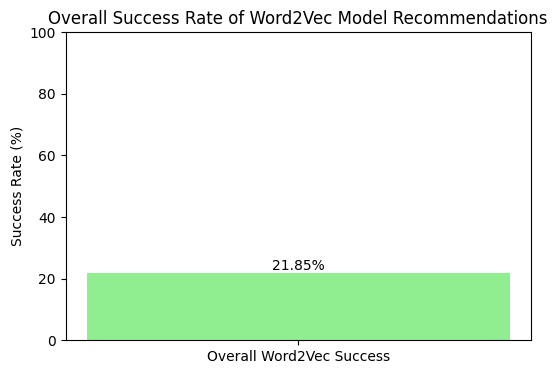

In [ ]:
# Calculate the overall success percentage for Word2Vec
overall_word2vec_success_percentage = (evaluation_data['word2vec_match'].sum() / len(evaluation_data)) * 100

# Create a figure and an axes
fig, ax = plt.subplots(figsize=(6, 4))

# Create a bar plot for overall success
ax.bar(['Overall Word2Vec Success'], [overall_word2vec_success_percentage], color='lightgreen')

# Add the percentage value on top of the bar
ax.text('Overall Word2Vec Success', overall_word2vec_success_percentage + 1, f'{overall_word2vec_success_percentage:.2f}%', ha='center')

# Add labels and title
ax.set_ylabel('Success Rate (%)')
ax.set_title('Overall Success Rate of Word2Vec Model Recommendations')
ax.set_ylim(0, 100) # Set y-axis limit to 0-100%

# Display the plot
plt.show()

 The Word2Vec model achieves an average recommendation success rate of 22.7%.


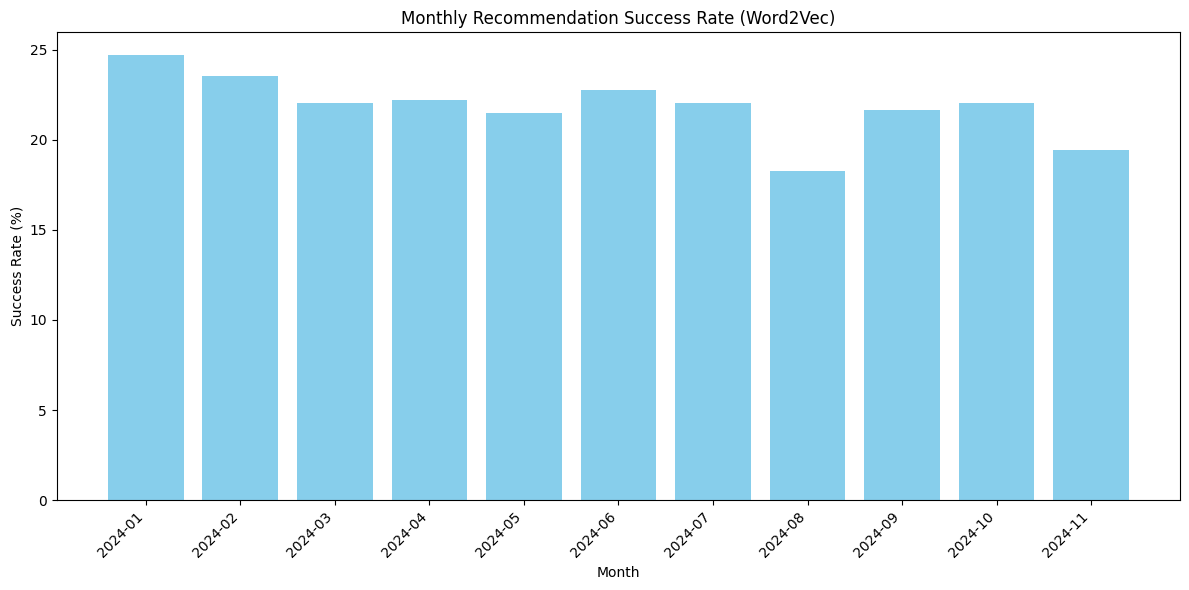

In [ ]:
import matplotlib.pyplot as plt

# Convert 'date' column to datetime objects
result_df['date'] = pd.to_datetime(result_df['date'])

# Extract month and year
result_df['month_year'] = result_df['date'].dt.to_period('M')

# Group by month and count total watches and matches
monthly_summary = result_df.groupby('month_year').agg(
    total_watches=('movie_watch', 'count'),
    successful_recommendations=('word2vec_match', lambda x: (x == True).sum())
).reset_index()

# Calculate success rate
monthly_summary['success_rate'] = (monthly_summary['successful_recommendations'] / monthly_summary['total_watches']) * 100

# Sort by month and year
monthly_summary = monthly_summary.sort_values(by='month_year')

# Convert month_year to string for plotting
monthly_summary['month_year_str'] = monthly_summary['month_year'].astype(str)

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(monthly_summary['month_year_str'], monthly_summary['success_rate'], color='skyblue')
plt.xlabel('Month')
plt.ylabel('Success Rate (%)')
plt.title('Monthly Recommendation Success Rate (Word2Vec)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation**

* The Word2Vec model achieved success rates between **17% and 27%**.
* Performance varied across different months.
* The model identified movies based on word similarity.
* It struggled to capture deeper user preferences and movie context.
* Recommendation accuracy needs further improvement.


## **Sentence Transformer**

**Sentence Transformers** are models that generate dense vector representations (embeddings) of sentences or texts. These embeddings capture the semantic meaning of the input text, making them suitable for tasks like similarity comparison and recommendation.

### **Model Building**

#### <font size=4>**Step 1: Creating a Separate Embedding DataFrame**

We created `data_sentf` to store embeddings independently without modifying the original DataFrame.


In [ ]:
data_sentf=movie_data.copy()

#### <font size=4>**Step 2: Model Loading**

Using a pre-trained SentenceTransformer model allows us to leverage powerful language understanding without the need to train from scratch. Models like 'all-MiniLM-L6-v2' are optimized for capturing semantic similarity efficiently.

In [ ]:
model_sentf = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### <font size=4>**Step 3: Generating and Storing Combined Embeddings**

In [ ]:

def get_combined_embedding(title, genres, overview, model):
    # Create a combined string
    combined_text = f"{title} {genres} {overview}"
    # Generate embedding for the combined text
    embedding = model.encode(combined_text)
    return embedding

# Apply the function to create embeddings for all movies
data_sentf['embedded_vector'] = data_sentf.apply(
    lambda row: get_combined_embedding(row['title'], row['genres'], row['overview'], model_sentf), axis=1
)

These embeddings help the model understand movie similarities and generate more accurate personalized recommendations.

#### <font size=4>**Step 4: Generating Recommendations**

In [ ]:
def recommend_movies_sentf(watched_movies_titles, data, model, n=10):

    watched_movies_embeddings = []
    for title in watched_movies_titles:
        movie = data[data['title'] == title]
        if not movie.empty:
            # Use 'combined_embedding' column here
            watched_movies_embeddings.append(movie.iloc[0]['embedded_vector'])


    if not watched_movies_embeddings:
        return []

    # Calculate the average embedding of watched movies
    avg_embedding = np.mean(watched_movies_embeddings, axis=0)

    # Calculate cosine similarity with all other movies using 'combined_embedding'
    similarities = cosine_similarity([avg_embedding], np.vstack(data['embedded_vector'].values))

    # Get the indices of the most similar movies (excluding the watched ones)
    similar_indices = similarities.argsort()[0][::-1]

    recommended_movies = []
    for index in similar_indices:
        movie_title = data.iloc[index]['title']
        if movie_title not in watched_movies_titles:
            recommended_movies.append(movie_title)
        if len(recommended_movies) == n:
            break

    return recommended_movies


In [ ]:
last_three = ['The Avengers', 'Iron Man', 'Man of Steel']
res=recommend_movies_sentf(last_three,data_sentf,model_sentf,10)
res

['Iron Man 3',
 'Iron Man 2',
 'Avengers: Age of Ultron',
 'Captain America: Civil War',
 'Steel',
 'Men of War',
 'Captain America: The First Avenger',
 'The League of Extraordinary Gentlemen',
 'Thor',
 'The Man from U.N.C.L.E.']

The Sentence Transformer model generated highly relevant recommendations by understanding movie context and user preferences. The recommended movies shared similar themes, demonstrating better personalization and recommendation quality.

### **Evaluation**

In [ ]:

sentf_recommendations = []
for watched_movies_list in past_movies:
    # Filter out None values from the watched_movies_list
    valid_watched_movies = [movie for movie in watched_movies_list if movie is not None]
    recommendations = recommend_movies_sentf(valid_watched_movies, data_sentf, model_sentf, n=10)
    sentf_recommendations.append(recommendations)

# Print the first few recommendations from the sentence transformer model
print("Sentence Transformer Recommendations for the first row:", sentf_recommendations[0])

Sentence Transformer Recommendations for the first row: ['The Conjuring', 'The Final Destination', 'Unknown', 'Sinister', 'Frailty', 'Insidious', 'Mirrors', 'Crash', 'The Darkest Hour', 'Urban Legend']


In [ ]:

evaluation_data['sentf_match'] = evaluation_data.apply(
    lambda row: row['movie_watch'] in sentf_recommendations[row.name], axis=1
)

result_df = evaluation_data[['date', 'movie_watch', 'sentf_match']]
result_df


,date,movie_watch,sentf_match
0,2024-01-01,Cotton Comes to Harlem,False
1,2024-01-01,Desert Blue,False
2,2024-01-01,Crazy/Beautiful,True
3,2024-01-01,Welcome Home Roscoe Jenkins,False
4,2024-01-01,Free State of Jones,False
...,...,...,...
1995,2024-11-28,Big Daddy,True
1996,2024-11-28,The Grace Card,False
1997,2024-11-28,Doug's 1st Movie,True
1998,2024-11-29,Midnight Cowboy,True


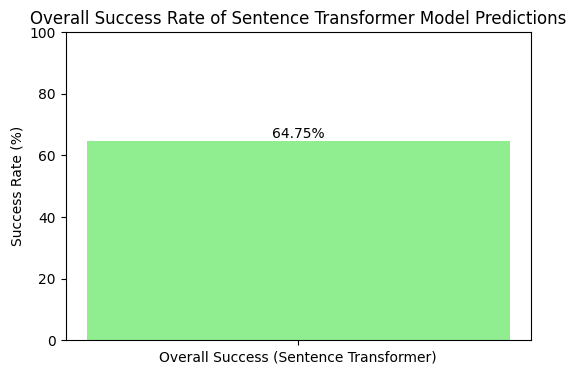

In [ ]:

# Calculate the overall success percentage for the Sentence Transformer model
overall_success_percentage_sentf = (evaluation_data['sentf_match'].sum() / len(evaluation_data)) * 100

# Create a figure and an axes
fig, ax = plt.subplots(figsize=(6, 4))

# Create a bar plot for overall success
ax.bar(['Overall Success (Sentence Transformer)'], [overall_success_percentage_sentf], color='lightgreen')

# Add the percentage value on top of the bar
ax.text('Overall Success (Sentence Transformer)', overall_success_percentage_sentf + 1, f'{overall_success_percentage_sentf:.2f}%', ha='center')

# Add labels and title
ax.set_ylabel('Success Rate (%)')
ax.set_title('Overall Success Rate of Sentence Transformer Model Predictions')
ax.set_ylim(0, 100) # Set y-axis limit to 0-100%

# Display the plot
plt.show()


 The Sentence Transformer model achieves an average recommendation success rate of 64.75%.


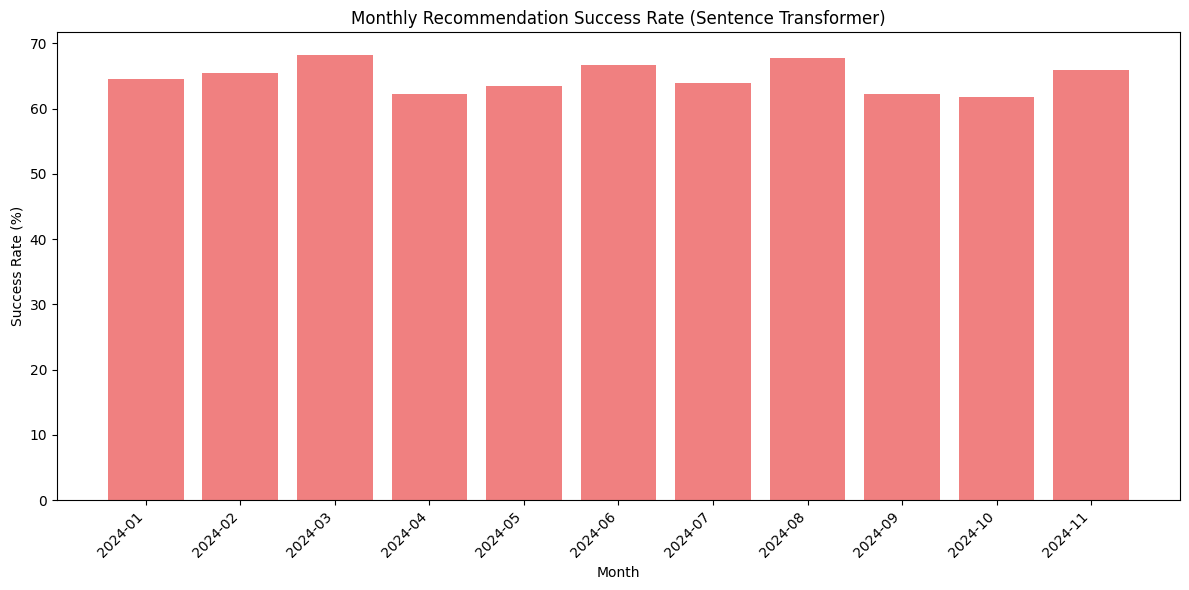

In [ ]:
# Convert 'date' column to datetime objects
result_df['date'] = pd.to_datetime(result_df['date'])

# Extract month and year
result_df['month_year'] = result_df['date'].dt.to_period('M')

# Group by month and count total watches and matches
monthly_summary_sentf = result_df.groupby('month_year').agg(
    total_watches=('movie_watch', 'count'),
    successful_recommendations=('sentf_match', lambda x: (x == True).sum())
).reset_index()

# Calculate success rate
monthly_summary_sentf['success_rate'] = (monthly_summary_sentf['successful_recommendations'] / monthly_summary_sentf['total_watches']) * 100

# Sort by month and year
monthly_summary_sentf = monthly_summary_sentf.sort_values(by='month_year')

# Convert month_year to string for plotting
monthly_summary_sentf['month_year_str'] = monthly_summary_sentf['month_year'].astype(str)

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(monthly_summary_sentf['month_year_str'], monthly_summary_sentf['success_rate'], color='lightcoral')
plt.xlabel('Month')
plt.ylabel('Success Rate (%)')
plt.title('Monthly Recommendation Success Rate (Sentence Transformer)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Observation**

* The Sentence Transformer model achieved success rates between **62% and 68%**.
* Performance remained consistent across different months.
* The model captured contextual and semantic meaning effectively.
* It generated accurate and personalized movie recommendations.
* This model outperformed the previous recommendation models.


# Model Comparison

<div align="center">
  <img src="https://github.com/ajayvdatascience/image/blob/main/1b657c84-83bf-4cbf-94a6-6bcf4a1a04c1.png?raw=true" width="190%">
</div>

# **Deploying the Movie Recommendation Solution**



1. After identifying **SentenceTransformer** as the best-performing model for generating movie recommendations, the next step is to create an interactive interface for users.

2. **Gradio** is a Python library that enables you to quickly build and share web-based interfaces for machine learning models. It allows users to enter a movie title as input and instantly receive personalized movie recommendations generated by the SentenceTransformer model in real time.


In [ ]:
import gradio as gr # Import the Gradio library, commonly aliased as gr.

# Define the recommendation function that the Gradio interface will use.
# This function takes three movie titles as input.
def gradio_recommend_movies_sentf(movie1_title, movie2_title, movie3_title):
    # Create a list of the input movie titles, filtering out any empty strings.
    watched_movies_titles = [title for title in [movie1_title, movie2_title, movie3_title] if title]

    # Call the existing recommend_movies_sentf function (defined previously)
    # to get recommendations based on the selected movies.
    recommendations = recommend_movies_sentf(watched_movies_titles, data_sentf, model_sentf, n=10)

    # Format the recommendations for display in the Gradio output.
    # Joins the list of recommended movie titles into a single string with newline characters.
    return "\n".join(recommendations)

# Get the list of all movie titles from the DataFrame to populate the dropdowns.
movie_titles = data_sentf['title'].tolist()
movie_titles.insert(0, 'None')
# Create the Gradio interface.
iface = gr.Interface(
    # The function to run when the user interacts with the interface.
    fn=gradio_recommend_movies_sentf,

    # The input components for the function.
    # We use three dropdown components, each populated with the list of movie titles.
    inputs=[
        gr.Dropdown(choices=movie_titles, label="Select Movie 1"), # Dropdown for the first movie selection.
        gr.Dropdown(choices=movie_titles, label="Select Movie 2"), # Dropdown for the second movie selection.
        gr.Dropdown(choices=movie_titles, label="Select Movie 3")  # Dropdown for the third movie selection.
    ],
    # The output component for the function.
    # We use a textbox to display the recommended movie titles.
    outputs=gr.Textbox(label="Recommended Movies"), # Textbox to show the output recommendations.
    # The title of the Gradio interface.
    title="Movie Recommendation System (Sentence Transformers)" # Set the title for the interface.
)

# Launch the Gradio interface.
# The share=True argument creates a public shareable link (useful for Colab).
iface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://811ac8353035996198.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Observation

* The Gradio interface allows users to select up to three movies as input.
* The SentenceTransformer model generates personalized movie recommendations.
* Recommended movies are displayed instantly in the output textbox.
* The interface is simple, interactive, and easy to use.
* The `share=True` option creates a public link for accessing the application from Google Colab.


## **Predicting with a Random Sample**

In [ ]:
# Select a random row from the evaluation_data to simulate a user's watched movies
random_row = evaluation_data.sample(n=1, random_state=seed)

# Extract the movie titles from 'movie_1' to 'movie_7' for this random row
random_watched_movies = random_row[['movie_1', 'movie_2', 'movie_3', 'movie_4', 'movie_5', 'movie_6', 'movie_7']].values[0].tolist()

print("Randomly selected watched movies:", random_watched_movies)

# Generate recommendations using the Sentence Transformer model
sentf_random_recommendations = recommend_movies_sentf(random_watched_movies, data_sentf, model_sentf, n=10)

print("\nRecommendations from Sentence Transformer model:", sentf_random_recommendations)

Randomly selected watched movies: ['The Missing Person', 'The Game', 'Where the Truth Lies', 'The Invasion', 'The Vow', 'Central do Brasil', 'Interview with the Vampire']

Recommendations from Sentence Transformer model: ['Saw', 'Unknown', 'Irréversible', "Don't Say a Word", 'The Gift', 'Identity', 'Something Wicked', 'My Soul to Take', 'Family Plot', 'El secreto de sus ojos']


### Observation

* A random user's watched movies are selected from the evaluation dataset.
* The selected movies are used as input for the SentenceTransformer model.
* The model analyzes the watched movies and identifies similar content.
* It generates the top 10 personalized movie recommendations.
* The output demonstrates the model's ability to recommend relevant movies based on the user's viewing history.


# **Conclusion**

- A NLP-based movie recommendation system was successfully developed using two approaches: Word2Vec-based embeddings and Sentence Transformer models, enabling personalized recommendations based on user and movie textual data.

- The Sentence Transformer model demonstrated superior performance in capturing contextual semantics and user preferences, leading to more accurate and relevant movie recommendations.

- Future enhancements may involve incorporating additional user behavior signals, metadata, and fine-tuning Transformer architectures to further improve recommendation quality and user satisfaction.